# Week 1 · Marvel network scaffold

Scaffold for exercises 1.6–1.8 on the frozen week-1 Marvel snapshot (303 characters, Wikipedia `Category:Marvel Comics superheroes`).

Source: [course data page](https://sunelehmann.com/socialgraphs2026-web/data/) · [week 1 instructions](https://sunelehmann.com/socialgraphs2026-web/weeks/week1.html)

This notebook only sets up the sections — the actual analysis, plots, and conclusions are for later. If `data/raw/marvel/week1/` is empty, run:

```
uv run scripts/download_marvel_week1.py
```

## 1. Load and validate data

Load the graph with every node added before any edge (so the 17 isolates survive), then check the snapshot against the numbers published on the course data page.

In [1]:
from sgi.marvel import (
    EXPECTED_DIRECTED_EDGE_COUNT,
    EXPECTED_ISOLATE_COUNT,
    EXPECTED_NODE_COUNT,
    EXPECTED_UNDIRECTED_COMPONENT_SIZES,
    EXPECTED_UNDIRECTED_EDGE_COUNT,
    load_marvel_graph,
    snapshot_report,
    to_undirected,
)

G = load_marvel_graph()
report = snapshot_report(G)
report

{'node_count': 303,
 'directed_edge_count': 1784,
 'undirected_edge_count': 1434,
 'isolate_count': 17,
 'undirected_component_sizes': [277,
  9,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1]}

In [2]:
# Checks, not hard-coded answers: compare what we computed above to what the
# course page says this frozen snapshot should look like.
checks = {
    "node_count": (report["node_count"], EXPECTED_NODE_COUNT),
    "directed_edge_count": (report["directed_edge_count"], EXPECTED_DIRECTED_EDGE_COUNT),
    "undirected_edge_count": (report["undirected_edge_count"], EXPECTED_UNDIRECTED_EDGE_COUNT),
    "isolate_count": (report["isolate_count"], EXPECTED_ISOLATE_COUNT),
}
for name, (actual, expected) in checks.items():
    status = "OK" if actual == expected else "MISMATCH"
    print(f"{name}: computed={actual} expected={expected} -> {status}")

sizes = sorted(report["undirected_component_sizes"], reverse=True)
expected_sizes = sorted(EXPECTED_UNDIRECTED_COMPONENT_SIZES, reverse=True)
print(f"component sizes match: {sizes == expected_sizes}")

node_count: computed=303 expected=303 -> OK
directed_edge_count: computed=1784 expected=1784 -> OK
undirected_edge_count: computed=1434 expected=1434 -> OK
isolate_count: computed=17 expected=17 -> OK
component sizes match: True


## 2. In-degree and out-degree distributions

Plot the in-degree and out-degree distributions (linear and log–log, against $k+1$ so isolates survive the log axis). See exercise 1.6.

in-degree range: 0-106
out-degree range: 0-28


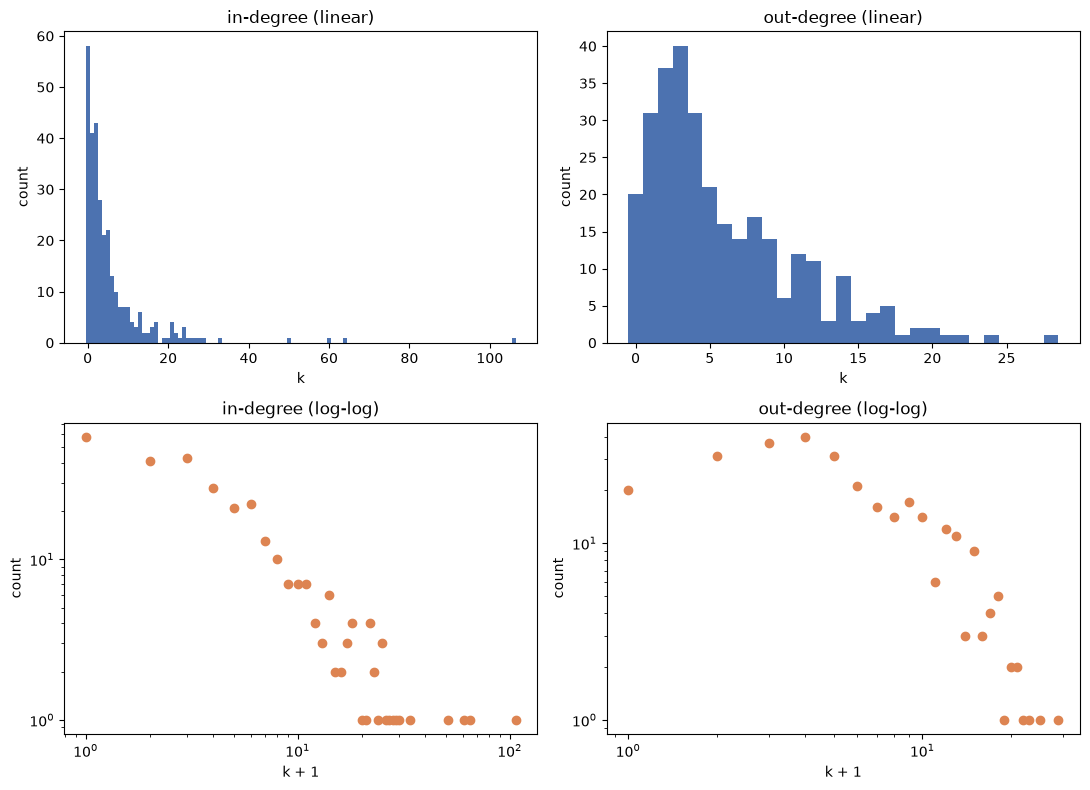

In [3]:
import matplotlib.pyplot as plt
import numpy as np

in_degrees = np.array([d for _, d in G.in_degree()])
out_degrees = np.array([d for _, d in G.out_degree()])

print(f"in-degree range: {in_degrees.min()}-{in_degrees.max()}")
print(f"out-degree range: {out_degrees.min()}-{out_degrees.max()}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, (degrees, label) in enumerate([(in_degrees, "in-degree"), (out_degrees, "out-degree")]):
    bins = np.arange(degrees.max() + 2) - 0.5
    axes[0, col].hist(degrees, bins=bins, color="#4C72B0")
    axes[0, col].set_title(f"{label} (linear)")
    axes[0, col].set_xlabel("k")
    axes[0, col].set_ylabel("count")

    values, counts = np.unique(degrees, return_counts=True)
    axes[1, col].scatter(values + 1, counts, color="#DD8452")
    axes[1, col].set_xscale("log")
    axes[1, col].set_yscale("log")
    axes[1, col].set_title(f"{label} (log-log)")
    axes[1, col].set_xlabel("k + 1")
    axes[1, col].set_ylabel("count")
fig.tight_layout()
fig.savefig("../website/src/pages/week1-assets/degree-distributions.png", dpi=150)
plt.show()

In [4]:
node_in = dict(G.in_degree())
node_out = dict(G.out_degree())
top5_in = sorted(node_in.items(), key=lambda kv: kv[1], reverse=True)[:5]
top5_out = sorted(node_out.items(), key=lambda kv: kv[1], reverse=True)[:5]
print("top 5 in-degree:", top5_in)
print("top 5 out-degree:", top5_out)

top 5 in-degree: [('Spider-Man', 106), ('Hulk', 64), ('Wolverine_(character)', 60), ('Doctor_Strange', 50), ('Deadpool', 33)]
top 5 out-degree: [('Betsy_Braddock', 28), ('Cloak_and_Dagger_(characters)', 24), ('Adam_Warlock', 22), ('Venom_(character)', 21), ('She-Hulk', 20)]


## 3. Visualization

Draw the network (giant component, force layout) per exercise 1.7/1.8.

giant component: 277 nodes, 1421 edges


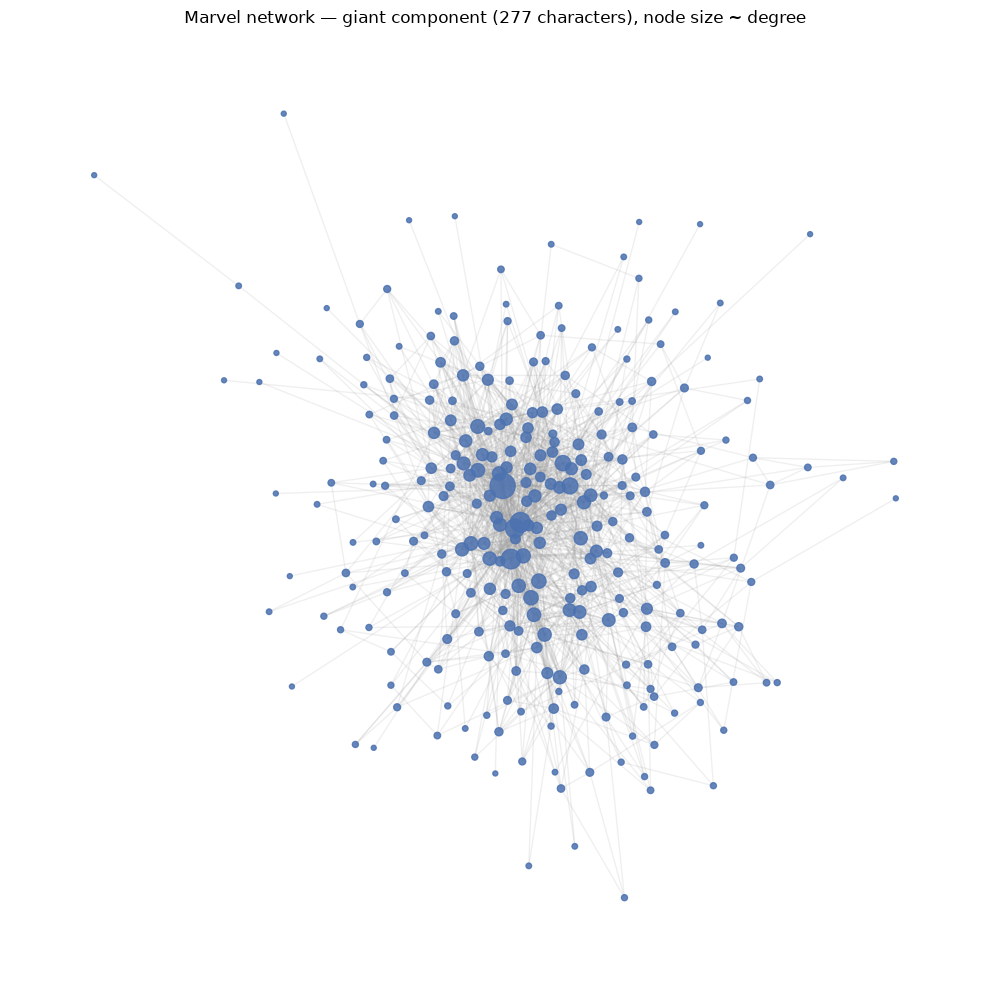

In [5]:
import networkx as nx

undirected = to_undirected(G)
giant_component_nodes = max(nx.connected_components(undirected), key=len)
giant = undirected.subgraph(giant_component_nodes)
print(f"giant component: {giant.number_of_nodes()} nodes, {giant.number_of_edges()} edges")

degrees = dict(giant.degree())
node_size = [10 + 3 * degrees[n] for n in giant.nodes()]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(giant, seed=7, k=0.2)
nx.draw_networkx_edges(giant, pos, alpha=0.15, edge_color="#999999")
nx.draw_networkx_nodes(giant, pos, node_size=node_size, node_color="#4C72B0", alpha=0.85)
plt.title("Marvel network — giant component (277 characters), node size ~ degree")
plt.axis("off")
plt.tight_layout()
plt.savefig("../website/src/pages/week1-assets/giant-component.png", dpi=150)
plt.show()

## 4. Our observations (write this later)

**TODO — not yet written.** Fill in after actually doing the analysis above: what you asked, what you found, what surprised you. Do not fabricate findings here.